Sales Dataset:
        Date Customer  Segment   Product  Quantity  Price     Month  Revenue
0 2026-01-05        A  Regular    Laptop         1  50000   January    50000
1 2026-01-10        B      New     Mouse         2    500   January     1000
2 2026-02-12        A  Regular  Keyboard         1   2000  February     2000
3 2026-02-18        C  Premium    Laptop         1  50000  February    50000
4 2026-03-05        B      New     Mouse         3    500     March     1500

Revenue by Segment:
Segment
New          2500
Premium    104000
Regular     53000
Name: Revenue, dtype: int64

Monthly Revenue:
Month
January     51000
February    52000
March       55500
April        1000
Name: Revenue, dtype: int64

Sales Pivot Table:
Month    April  February  January  March
Segment                                 
New          0         0     1000   1500
Premium      0     50000        0  54000
Regular   1000      2000    50000      0


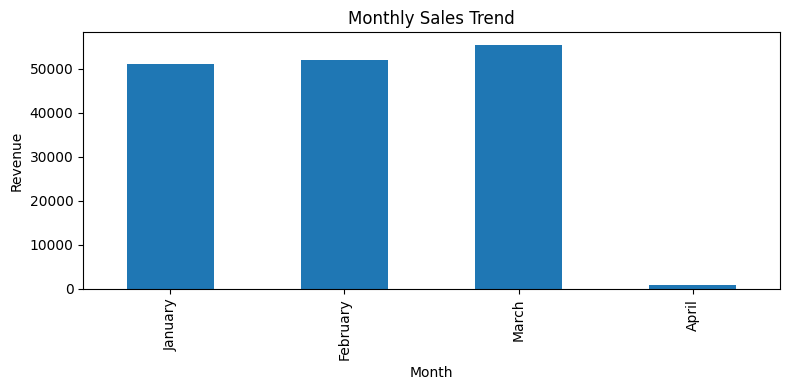


Top Customers:
Customer
C    54000
A    53000
D    50000
B     2500
Name: Revenue, dtype: int64

Business Recommendations:
- Focus on customer segments generating high revenue.
- Monitor monthly sales trends.
- Promote products with higher sales.

Sales Analysis Completed Successfully!


In [1]:

import pandas as pd
import matplotlib.pyplot as plt

# Create sample e-commerce sales data
df = pd.DataFrame({
    "Date": ["2026-01-05", "2026-01-10", "2026-02-12",
             "2026-02-18", "2026-03-05", "2026-03-15",
             "2026-03-20", "2026-04-10"],
    "Customer": ["A", "B", "A", "C", "B", "D", "C", "A"],
    "Segment": ["Regular", "New", "Regular", "Premium",
                "New", "Premium", "Premium", "Regular"],
    "Product": ["Laptop", "Mouse", "Keyboard", "Laptop",
                "Mouse", "Laptop", "Keyboard", "Mouse"],
    "Quantity": [1, 2, 1, 1, 3, 1, 2, 2],
    "Price": [50000, 500, 2000, 50000, 500, 50000, 2000, 500]
})

# Feature engineering
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month_name()
df["Revenue"] = df["Quantity"] * df["Price"]

print("Sales Dataset:")
print(df.head())

# Revenue by customer segment
print("\nRevenue by Segment:")
print(df.groupby("Segment")["Revenue"].sum())

# Monthly sales trend
monthly = df.groupby("Month", sort=False)["Revenue"].sum()
print("\nMonthly Revenue:")
print(monthly)

# Pivot table
pivot = pd.pivot_table(
    df, values="Revenue",
    index="Segment", columns="Month",
    aggfunc="sum", fill_value=0
)
print("\nSales Pivot Table:")
print(pivot)

# Sales trend chart
monthly.plot(kind="bar", title="Monthly Sales Trend",
             xlabel="Month", ylabel="Revenue",
             figsize=(8, 4))
plt.tight_layout()
plt.show()

# Top customer analysis
print("\nTop Customers:")
print(df.groupby("Customer")["Revenue"].sum()
      .sort_values(ascending=False))

# Business recommendations
print("\nBusiness Recommendations:")
print("- Focus on customer segments generating high revenue.")
print("- Monitor monthly sales trends.")
print("- Promote products with higher sales.")
print("\nSales Analysis Completed Successfully!")